# Hoja de trabajo 2. Transformers y mecanismos de atención

Roberto Barreda, 23354. CC3092 Deep Learning y Sistemas Inteligentes.

In [1]:
import math
import os
import time
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from transformers import AutoTokenizer, AutoModel
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("figures", exist_ok=True)

# Paleta de las gráficas
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, GRIS = "#0b0b0b", "#52514e"
MAPA = LinearSegmentedColormap.from_list(
    "azules", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": GRIS, "ytick.color": GRIS, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e4e3df",
    "grid.linewidth": 0.6, "lines.linewidth": 2, "legend.frameon": False,
})
print(device, torch.__version__)

cuda 2.13.0+cu130


## 1. Implementación de scaled dot-product attention

La función calcula $\mathrm{softmax}(QK^T / \sqrt{d_k})\,V$. La máscara booleana marca con True las posiciones que cada consulta puede ver, igual que en `F.scaled_dot_product_attention`.

In [2]:
def atencion(Q, K, V, mascara=None):
    """Devuelve la salida y los pesos de atención. Q, K y V tienen forma (..., n, d)."""
    d_k = Q.size(-1)
    puntajes = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mascara is not None:
        puntajes = puntajes.masked_fill(~mascara, float("-inf"))
    pesos = torch.softmax(puntajes, dim=-1)
    return pesos @ V, pesos


def mascara_causal(n, device=None):
    # True en la diagonal y debajo de ella
    return torch.ones(n, n, dtype=torch.bool, device=device).tril()

## 2. Ejercicio a mano

Tres tokens con d_k = 2. Se calcula cada paso y se compara con los valores obtenidos en papel.

In [3]:
Q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
K = torch.tensor([[1., 1.], [0., 1.], [1., 0.]])
V = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])

puntajes = Q @ K.T
escalados = puntajes / math.sqrt(Q.size(-1))
pesos = torch.softmax(escalados, dim=-1)
salida = pesos @ V
for nombre, t in [("QK^T", puntajes), ("QK^T / sqrt(2)", escalados),
                  ("softmax por fila", pesos), ("salida = pesos V", salida)]:
    print(nombre, "\n", t.numpy().round(4), "\n")

# Versión causal: cada token solo ve los anteriores y a sí mismo
salida_c, pesos_c = atencion(Q, K, V, mascara_causal(3))
print("pesos causales\n", pesos_c.numpy().round(4))
print("salida causal\n", salida_c.numpy().round(4))

QK^T 
 [[1. 0. 1.]
 [1. 1. 0.]
 [2. 1. 1.]] 

QK^T / sqrt(2) 
 [[0.7071 0.     0.7071]
 [0.7071 0.7071 0.    ]
 [1.4142 0.7071 0.7071]] 

softmax por fila 
 [[0.4011 0.1978 0.4011]
 [0.4011 0.4011 0.1978]
 [0.5035 0.2483 0.2483]] 

salida = pesos V 
 [[3.     4.    ]
 [2.5933 3.5933]
 [2.4895 3.4895]] 

pesos causales
 [[1.     0.     0.    ]
 [0.5    0.5    0.    ]
 [0.5035 0.2483 0.2483]]
salida causal
 [[1.     2.    ]
 [2.     3.    ]
 [2.4895 3.4895]]


In [4]:
# Resultados del cálculo en papel con cuatro decimales
pesos_mano = torch.tensor([[0.4011, 0.1978, 0.4011],
                           [0.4011, 0.4011, 0.1978],
                           [0.5035, 0.2483, 0.2483]])
salida_mano = torch.tensor([[3.0000, 4.0000], [2.5933, 3.5933], [2.4895, 3.4895]])
salida_causal_mano = torch.tensor([[1.0000, 2.0000], [2.0000, 3.0000], [2.4895, 3.4895]])

print("pesos coinciden:", torch.allclose(pesos, pesos_mano, atol=1e-4))
print("salida coincide:", torch.allclose(salida, salida_mano, atol=1e-4))
print("salida causal coincide:", torch.allclose(salida_c, salida_causal_mano, atol=1e-4))

pesos coinciden: True
salida coincide: True
salida causal coincide: True


## 3. Verificaciones contra PyTorch

Se compara la implementación propia con `F.scaled_dot_product_attention`, con `nn.MultiheadAttention` usando los mismos pesos y con la máscara de `nn.Transformer`.

In [5]:
verificaciones = []
B, H, n, d = 2, 4, 10, 16
q, k, v = (torch.randn(B, H, n, d) for _ in range(3))

# Sin máscara y con máscara causal
out_propia, _ = atencion(q, k, v)
out_sdpa = F.scaled_dot_product_attention(q, k, v)
verificaciones.append(("Propia vs SDPA sin máscara", (out_propia - out_sdpa).abs().max().item()))

out_propia_c, pesos_rand_c = atencion(q, k, v, mascara_causal(n))
out_sdpa_c = F.scaled_dot_product_attention(q, k, v, is_causal=True)
verificaciones.append(("Propia vs SDPA causal", (out_propia_c - out_sdpa_c).abs().max().item()))
verificaciones.append(("Suma de cada fila menos 1", (pesos_rand_c.sum(-1) - 1).abs().max().item()))
verificaciones.append(("Peso máximo sobre la diagonal", pesos_rand_c.triu(1).max().item()))

# Multi-head propia contra nn.MultiheadAttention
d_model, h = 32, 4
mha = nn.MultiheadAttention(d_model, h, batch_first=True).eval()
x = torch.randn(B, n, d_model)
with torch.no_grad():
    out_mha, pesos_mha = mha(x, x, x, need_weights=True, average_attn_weights=False)
    W_q, W_k, W_v = mha.in_proj_weight.chunk(3)
    b_q, b_k, b_v = mha.in_proj_bias.chunk(3)

    def dividir(t):
        # (B, n, d_model) a (B, h, n, d_model / h)
        return t.view(B, n, h, d_model // h).transpose(1, 2)

    out_h, pesos_h = atencion(dividir(x @ W_q.T + b_q), dividir(x @ W_k.T + b_k),
                              dividir(x @ W_v.T + b_v))
    out_propia_mha = mha.out_proj(out_h.transpose(1, 2).reshape(B, n, d_model))
verificaciones.append(("Multi-head propia vs nn.MultiheadAttention", (out_propia_mha - out_mha).abs().max().item()))
verificaciones.append(("Pesos por cabeza propios vs nn.MultiheadAttention", (pesos_h - pesos_mha).abs().max().item()))

# Máscara de PyTorch: 0 donde se permite y -inf donde se bloquea
m = nn.Transformer.generate_square_subsequent_mask(n)
verificaciones.append(("Posiciones distintas entre máscara de PyTorch y propia",
                       float(((m == 0) != mascara_causal(n)).sum())))

pd.set_option("display.float_format", "{:.2e}".format)
tabla_verif = pd.DataFrame(verificaciones, columns=["Verificación", "Error máximo"])
tabla_verif

,Verificación,Error máximo
0,Propia vs SDPA sin máscara,3.58e-07
1,Propia vs SDPA causal,2.38e-07
2,Suma de cada fila menos 1,1.79e-07
3,Peso máximo sobre la diagonal,0.00e+00
4,Multi-head propia vs nn.MultiheadAttention,5.96e-08
5,Pesos por cabeza propios vs nn.MultiheadAttention,5.96e-08
6,Posiciones distintas entre máscara de PyTorch ...,0.00e+00


In [6]:
# Número de parámetros con una cabeza y con ocho cabezas
for cabezas in (1, 8):
    capa = nn.MultiheadAttention(512, cabezas)
    print(f"{cabezas} cabeza(s): {sum(p.numel() for p in capa.parameters()):,} parámetros")

# Capa de encoder Pre-LN con máscara causal
capa = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=64, dropout=0.1,
                                  batch_first=True, norm_first=True).eval()
print("Salida del encoder:", tuple(capa(x, src_mask=m, is_causal=True).shape))
print(m[:4, :4])

1 cabeza(s): 1,050,624 parámetros
8 cabeza(s): 1,050,624 parámetros
Salida del encoder: (2, 10, 32)
tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])


La implementación propia coincide con PyTorch con errores menores a 1e-6, que corresponden al redondeo de float32. Las filas suman 1, los pesos sobre la diagonal son 0 con la máscara causal y `generate_square_subsequent_mask` bloquea las mismas posiciones. Con 1 y con 8 cabezas la capa tiene 1,050,624 parámetros, ya que dividir d_model entre las cabezas no cambia el tamaño de las proyecciones.

## 4. Escalamiento del producto punto

Con componentes de q y k independientes, media 0 y varianza 1, la varianza de $q \cdot k$ crece con $d_k$. Se mide esa varianza y el efecto sobre la softmax con 32 llaves.

In [7]:
dims = [4, 16, 64, 256, 1024]
var_sin, var_con = [], []
ent_sin, ent_con, jac_sin, jac_con, max_sin, max_con = [], [], [], [], [], []
n_llaves = 32

def jacobiano_softmax(p):
    # J = diag(p) - p p^T, se devuelve su norma de Frobenius
    J = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)
    return torch.linalg.matrix_norm(J).mean().item()

def entropia(p):
    return -(p * torch.log(p.clamp_min(1e-12))).sum(-1)

for d in dims:
    qv, kv = torch.randn(50_000, d), torch.randn(50_000, d)
    prod = (qv * kv).sum(-1)
    var_sin.append(prod.var().item())
    var_con.append((prod / math.sqrt(d)).var().item())

    qs, ks = torch.randn(4000, 1, d), torch.randn(4000, n_llaves, d)
    logits = (qs @ ks.transpose(-2, -1)).squeeze(1)
    for lg, ent, jac, mx in [(logits, ent_sin, jac_sin, max_sin),
                             (logits / math.sqrt(d), ent_con, jac_con, max_con)]:
        p = torch.softmax(lg, dim=-1)
        ent.append((entropia(p) / math.log(n_llaves)).mean().item())
        jac.append(jacobiano_softmax(p))
        mx.append(p.max(-1).values.mean().item())

tabla_esc = pd.DataFrame({"d_k": dims, "var sin escalar": var_sin, "var escalada": var_con,
                          "peso max sin escalar": max_sin, "peso max escalado": max_con,
                          "norma J sin escalar": jac_sin, "norma J escalada": jac_con})
tabla_esc.style.format(precision=3)

,d_k,var sin escalar,var escalada,peso max sin escalar,peso max escalado,norma J sin escalar,norma J escalada
0,4,3.997,0.999,0.346,0.159,0.295,0.235
1,16,15.950,0.997,0.627,0.162,0.291,0.239
2,64,65.219,1.019,0.819,0.164,0.193,0.241
3,256,257.213,1.005,0.915,0.166,0.107,0.241
4,1024,1024.091,1.000,0.960,0.167,0.055,0.242


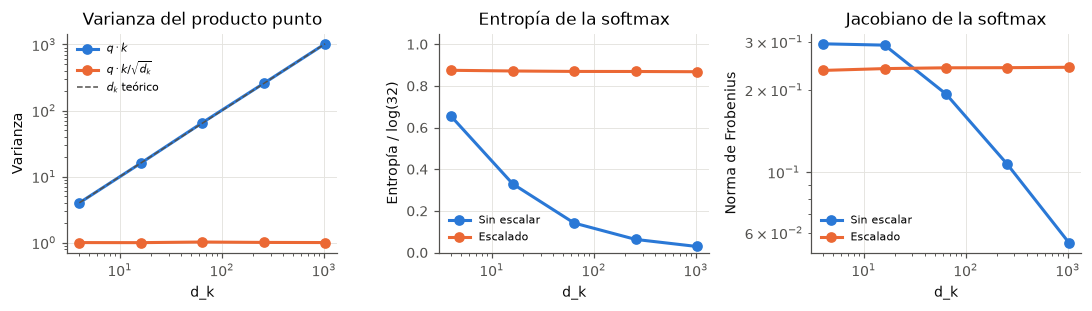

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(10, 2.9))
ax[0].plot(dims, var_sin, "o-", color=AZUL, label=r"$q \cdot k$")
ax[0].plot(dims, var_con, "o-", color=NARANJA, label=r"$q \cdot k / \sqrt{d_k}$")
ax[0].plot(dims, dims, "--", color=GRIS, lw=1, label=r"$d_k$ teórico")
ax[0].set(xscale="log", yscale="log", xlabel="d_k", ylabel="Varianza", title="Varianza del producto punto")

ax[1].plot(dims, ent_sin, "o-", color=AZUL, label="Sin escalar")
ax[1].plot(dims, ent_con, "o-", color=NARANJA, label="Escalado")
ax[1].set(xscale="log", ylim=(0, 1.05), xlabel="d_k", ylabel="Entropía / log(32)", title="Entropía de la softmax")

ax[2].plot(dims, jac_sin, "o-", color=AZUL, label="Sin escalar")
ax[2].plot(dims, jac_con, "o-", color=NARANJA, label="Escalado")
ax[2].set(xscale="log", yscale="log", xlabel="d_k", ylabel="Norma de Frobenius", title="Jacobiano de la softmax")
for a in ax:
    a.legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/escalamiento.png")
plt.show()

La varianza de $q \cdot k$ sin escalar es igual a $d_k$ y con el escalamiento queda en 1. Sin escalar, la entropía normalizada cae de 0.65 a 0.03 y el peso máximo sube de 0.35 a 0.96, por lo que la softmax se acerca a un vector one-hot. La norma del jacobiano baja de 0.30 a 0.055 y con ella el gradiente que reciben Q y K. Con el escalamiento la entropía y el jacobiano no dependen de d_k.

## 5. Costo computacional

Se mide tiempo y memoria pico de la atención propia, que guarda la matriz n x n, contra `F.scaled_dot_product_attention`. Se usan 8 cabezas, d = 64 y float16 en GPU.

In [9]:
from torch.nn.attention import sdpa_kernel, SDPBackend

def sincronizar():
    if device == "cuda":
        torch.cuda.synchronize()

def medir_tiempo(fn, reps=10):
    for _ in range(3):
        fn()
    sincronizar()
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    sincronizar()
    return (time.perf_counter() - t0) / reps * 1000

def medir_memoria(fn):
    if device != "cuda":
        return float("nan")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    base = torch.cuda.memory_allocated()
    fn()
    sincronizar()
    return (torch.cuda.max_memory_allocated() - base) / 2**20

# Backends de SDPA disponibles en esta instalación
disponibles = []
for nombre, b in [("flash", SDPBackend.FLASH_ATTENTION), ("eficiente", SDPBackend.EFFICIENT_ATTENTION)]:
    try:
        with sdpa_kernel(b), warnings.catch_warnings():
            warnings.simplefilter("ignore")
            z = torch.randn(1, 1, 128, 64, device=device, dtype=torch.float16 if device == "cuda" else torch.float32)
            F.scaled_dot_product_attention(z, z, z)
        disponibles.append((nombre, b))
    except RuntimeError:
        pass
print("Backends disponibles:", [d for d, _ in disponibles])
backend_nombre, backend = disponibles[0] if disponibles else ("math", SDPBackend.MATH)

Backends disponibles: ['eficiente']


In [10]:
dtype = torch.float16 if device == "cuda" else torch.float32
ns = [256, 512, 1024, 2048, 4096, 8192, 16384] if device == "cuda" else [128, 256, 512, 1024, 2048]
filas = []
for n_seq in ns:
    q = torch.randn(1, 8, n_seq, 64, device=device, dtype=dtype)
    k, v = torch.randn_like(q), torch.randn_like(q)
    fila = {"n": n_seq}
    with torch.no_grad():
        try:
            fila["ms propia"] = medir_tiempo(lambda: atencion(q, k, v))
            fila["MB propia"] = medir_memoria(lambda: atencion(q, k, v))
        except torch.OutOfMemoryError:
            fila["ms propia"] = fila["MB propia"] = float("nan")
        if device == "cuda":
            torch.cuda.empty_cache()
        with sdpa_kernel(backend):
            fila["ms SDPA"] = medir_tiempo(lambda: F.scaled_dot_product_attention(q, k, v))
            fila["MB SDPA"] = medir_memoria(lambda: F.scaled_dot_product_attention(q, k, v))
    filas.append(fila)
    del q, k, v

tabla_costo = pd.DataFrame(filas)
tabla_costo.style.format(precision=2)

,n,ms propia,MB propia,ms SDPA,MB SDPA
0,256,0.07,2.25,0.02,0.25
1,512,0.08,8.50,0.03,0.50
2,1024,0.11,33.00,0.08,1.00
3,2048,1.07,130.00,0.24,2.00
4,4096,4.23,516.00,0.80,4.00
5,8192,16.66,2056.00,2.60,8.00
6,16384,65.70,8208.00,10.84,16.00


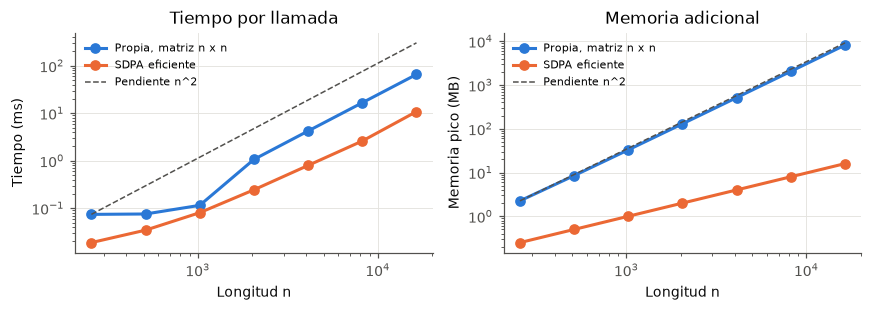

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(8, 2.9))
ax[0].plot(tabla_costo["n"], tabla_costo["ms propia"], "o-", color=AZUL, label="Propia, matriz n x n")
ax[0].plot(tabla_costo["n"], tabla_costo["ms SDPA"], "o-", color=NARANJA, label=f"SDPA {backend_nombre}")
ax[0].set(xscale="log", yscale="log", xlabel="Longitud n", ylabel="Tiempo (ms)", title="Tiempo por llamada")
ax[1].plot(tabla_costo["n"], tabla_costo["MB propia"], "o-", color=AZUL, label="Propia, matriz n x n")
ax[1].plot(tabla_costo["n"], tabla_costo["MB SDPA"], "o-", color=NARANJA, label=f"SDPA {backend_nombre}")
ax[1].set(xscale="log", yscale="log", xlabel="Longitud n", ylabel="Memoria pico (MB)", title="Memoria adicional")

# Referencia de pendiente cuadrática anclada al primer punto de la versión propia
ref = tabla_costo["n"].to_numpy(dtype=float)
for a, col in [(ax[0], "ms propia"), (ax[1], "MB propia")]:
    y0 = tabla_costo[col].iloc[0]
    a.plot(ref, y0 * (ref / ref[0]) ** 2, "--", color=GRIS, lw=1, label="Pendiente n^2")
    a.legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/costo.png")
plt.show()

La memoria de la versión propia crece con n^2 y llega a 8,208 MB con n = 16,384, que es lo que ocupan las matrices de puntajes y pesos en float16. El kernel eficiente de SDPA usa 16 MB porque procesa la atención por bloques sin guardar la matriz n x n. El tiempo crece con n^2 en ambos casos porque el número de operaciones es el mismo, pero SDPA tarda 10.8 ms contra 65.7 ms de la versión propia en n = 16,384. Esta instalación de PyTorch en Windows no trae FlashAttention, por eso se usó el kernel de memoria eficiente.

## 6. Modelos preentrenados

Se cargan BERT y GPT-2 con la implementación eager para que devuelvan las atenciones. Cada modelo entrega una tupla con un tensor por capa de forma batch x cabezas x n x n.

In [12]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()


def atenciones(texto, tok, modelo):
    """Devuelve los tokens y un tensor (capas, cabezas, n, n) para una oración."""
    enc = tok(texto, return_tensors="pt")
    with torch.no_grad():
        out = modelo(**enc)
    A = torch.stack(out.attentions)[:, 0]
    # GPT-2 marca el espacio previo con el carácter U+0120
    tokens = [t.replace("\u0120", "") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return tokens, A


frase = "The cat sat on the mat, and the cat was happy."
tok_b, A_b = atenciones(frase, tok_bert, bert)
tok_g, A_g = atenciones(frase, tok_gpt2, gpt2)
print(len(A_b), "capas BERT", tuple(A_b.shape), tok_b)
print(len(A_g), "capas GPT-2", tuple(A_g.shape), tok_g)

12 capas BERT (12, 12, 15, 15) ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', ',', 'and', 'the', 'cat', 'was', 'happy', '.', '[SEP]']
12 capas GPT-2 (12, 12, 13, 13) ['The', 'cat', 'sat', 'on', 'the', 'mat', ',', 'and', 'the', 'cat', 'was', 'happy', '.']


## 7. Patrones por cabeza y mapas de calor

Para cada cabeza se mide la atención promedio al token anterior, al siguiente, a sí mismo, al primer token, a [SEP], a la puntuación y a otra aparición de la misma palabra. Se eligen cuatro cabezas de capas distintas con el patrón más marcado.

In [13]:
PUNTUACION = {",", ".", "!", "?", ";", ":"}

def patrones(A, tokens):
    L, Hc, n, _ = A.shape
    i = torch.arange(n)
    res = {
        "anterior": A[:, :, i[1:], i[:-1]].mean(-1),
        "siguiente": A[:, :, i[:-1], i[1:]].mean(-1),
        "misma posición": A.diagonal(dim1=-2, dim2=-1).mean(-1),
        "primer token": A[:, :, :, 0].mean(-1),
        "último token": A[:, :, :, -1].mean(-1),
        "puntuación": A[:, :, :, [j for j, t in enumerate(tokens) if t in PUNTUACION]].sum(-1).mean(-1),
    }
    # Misma palabra en otra posición
    pares = [(a, b) for a in range(n) for b in range(n) if a != b and tokens[a] == tokens[b]
             and tokens[a] not in PUNTUACION]
    filas = sorted({a for a, _ in pares})
    misma = torch.zeros(L, Hc)
    for a in filas:
        misma += A[:, :, a, [b for x, b in pares if x == a]].sum(-1)
    res["misma palabra"] = misma / len(filas)
    return res

def elegir_cabezas(res, claves):
    usadas, elegidas = set(), []
    for c in claves:
        orden = torch.argsort(res[c].flatten(), descending=True)
        for idx in orden.tolist():
            capa, cabeza = divmod(idx, res[c].shape[1])
            if capa not in usadas:
                usadas.add(capa)
                elegidas.append((c, capa, cabeza, res[c][capa, cabeza].item()))
                break
    return elegidas

def mejor_por_patron(res, nombre_modelo):
    filas = []
    for c, val in res.items():
        idx = val.flatten().argmax().item()
        capa, cabeza = divmod(idx, val.shape[1])
        filas.append({"modelo": nombre_modelo, "patrón": c, "capa": capa, "cabeza": cabeza,
                      "valor": val[capa, cabeza].item(), "promedio de cabezas": val.mean().item()})
    return filas

pat_b, pat_g = patrones(A_b, tok_b), patrones(A_g, tok_g)
pat_b["[CLS]"], pat_b["[SEP]"] = pat_b.pop("primer token"), pat_b.pop("último token")
pat_g.pop("último token")
pd.set_option("display.float_format", "{:.3f}".format)
pd.DataFrame(mejor_por_patron(pat_b, "BERT") + mejor_por_patron(pat_g, "GPT-2"))

,modelo,patrón,capa,cabeza,valor,promedio de cabezas
0,BERT,anterior,3,5,0.606,0.073
1,BERT,siguiente,2,9,0.929,0.102
2,BERT,misma posición,11,8,0.402,0.101
3,BERT,puntuación,11,7,0.903,0.176
4,BERT,misma palabra,3,0,0.827,0.073
5,BERT,[CLS],1,6,0.840,0.122
6,BERT,[SEP],5,1,0.869,0.312
7,GPT-2,anterior,4,11,1.000,0.166
8,GPT-2,siguiente,0,0,0.000,0.000
9,GPT-2,misma posición,0,1,0.895,0.160


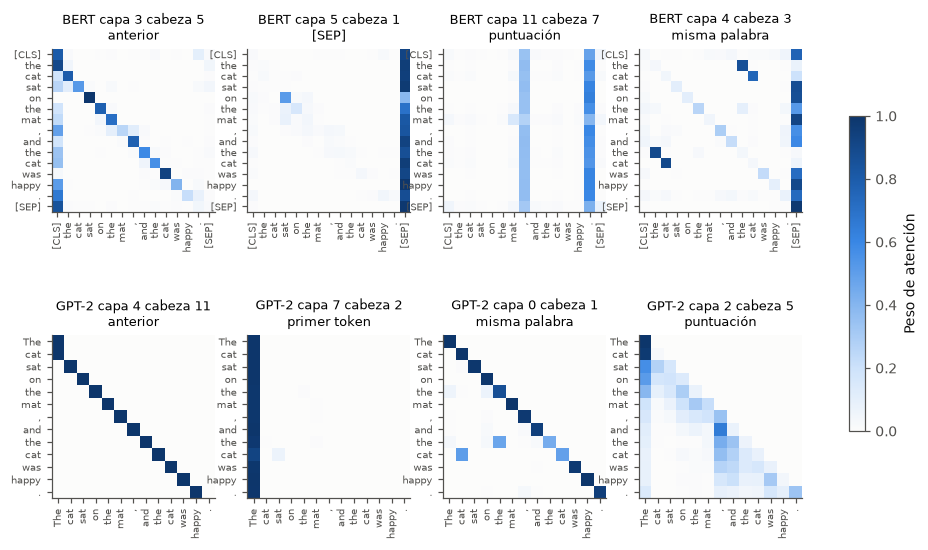

,modelo,patrón,capa,cabeza,valor
0,BERT,anterior,3,5,0.606
1,BERT,[SEP],5,1,0.869
2,BERT,puntuación,11,7,0.903
3,BERT,misma palabra,4,3,0.710
4,GPT-2,anterior,4,11,1.000
5,GPT-2,primer token,7,2,0.989
6,GPT-2,misma palabra,0,1,0.244
7,GPT-2,puntuación,2,5,0.204


In [14]:
sel_b = elegir_cabezas(pat_b, ["anterior", "[SEP]", "puntuación", "misma palabra"])
sel_g = elegir_cabezas(pat_g, ["anterior", "primer token", "misma palabra", "puntuación"])

def mapa(ax, A, tokens, titulo):
    ax.imshow(A, cmap=MAPA, vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)), tokens, rotation=90, fontsize=6.5)
    ax.set_yticks(range(len(tokens)), tokens, fontsize=6.5)
    ax.grid(False)
    ax.set_title(titulo, fontsize=8.5)

fig, axes = plt.subplots(2, 4, figsize=(11, 6.2))
for fila, (sel, A, toks, nombre) in enumerate([(sel_b, A_b, tok_b, "BERT"), (sel_g, A_g, tok_g, "GPT-2")]):
    for col, (patron, capa, cabeza, val) in enumerate(sel):
        mapa(axes[fila, col], A[capa, cabeza], toks, f"{nombre} capa {capa} cabeza {cabeza}\n{patron}")
fig.colorbar(axes[0, 0].images[0], ax=axes, shrink=0.6, label="Peso de atención")
fig.savefig("figures/mapas_calor.png")
plt.show()
pd.DataFrame([("BERT",) + s for s in sel_b] + [("GPT-2",) + s for s in sel_g],
             columns=["modelo", "patrón", "capa", "cabeza", "valor"])

En BERT la cabeza 5 de la capa 3 atiende al token anterior, la cabeza 1 de la capa 5 envía 0.87 de la atención a [SEP], la cabeza 7 de la capa 11 atiende a la coma y al punto y la cabeza 3 de la capa 4 conecta cada "cat" y cada "the" con su otra aparición. En GPT-2 la cabeza 11 de la capa 4 pone peso 1.0 en el token anterior, la cabeza 2 de la capa 7 manda la atención al primer token, la cabeza 1 de la capa 0 atiende a la misma posición y a la aparición previa de la misma palabra y la cabeza 5 de la capa 2 atiende a la coma después de que aparece. El patrón de token siguiente vale 0 en GPT-2 por la máscara causal.

## 8. Correferencia de "it" en BERT

Se busca una cabeza donde "it" atienda más a "animal" cuando la oración termina en tired y más a "street" cuando termina en wide. El puntaje de cada cabeza es el mínimo de las dos diferencias, así solo es positivo si se cumplen ambos casos.

In [15]:
s_tired = "The animal didn't cross the street because it was too tired."
s_wide = "The animal didn't cross the street because it was too wide."
tok_t, A_t = atenciones(s_tired, tok_bert, bert)
tok_w, A_w = atenciones(s_wide, tok_bert, bert)
i_it, i_an, i_st = tok_t.index("it"), tok_t.index("animal"), tok_t.index("street")

dif_tired = A_t[:, :, i_it, i_an] - A_t[:, :, i_it, i_st]   # positivo favorece animal
dif_wide = A_w[:, :, i_it, i_st] - A_w[:, :, i_it, i_an]    # positivo favorece street
puntaje = torch.minimum(dif_tired, dif_wide)

filas = []
for idx in torch.argsort(puntaje.flatten(), descending=True)[:5].tolist():
    capa, cabeza = divmod(idx, puntaje.shape[1])
    filas.append({"capa": capa, "cabeza": cabeza,
                  "tired: it a animal": A_t[capa, cabeza, i_it, i_an].item(),
                  "tired: it a street": A_t[capa, cabeza, i_it, i_st].item(),
                  "wide: it a animal": A_w[capa, cabeza, i_it, i_an].item(),
                  "wide: it a street": A_w[capa, cabeza, i_it, i_st].item(),
                  "puntaje": puntaje[capa, cabeza].item()})
tabla_it = pd.DataFrame(filas)
print("Cabezas que cumplen ambos casos:", int((puntaje > 0).sum()), "de", puntaje.numel())
tabla_it

Cabezas que cumplen ambos casos: 22 de 144


,capa,cabeza,tired: it a animal,tired: it a street,wide: it a animal,wide: it a street,puntaje
0,6,10,0.284,0.067,0.012,0.590,0.217
1,8,4,0.242,0.014,0.046,0.209,0.163
2,8,7,0.205,0.050,0.061,0.194,0.133
3,4,10,0.333,0.095,0.167,0.288,0.121
4,6,4,0.239,0.134,0.081,0.251,0.105


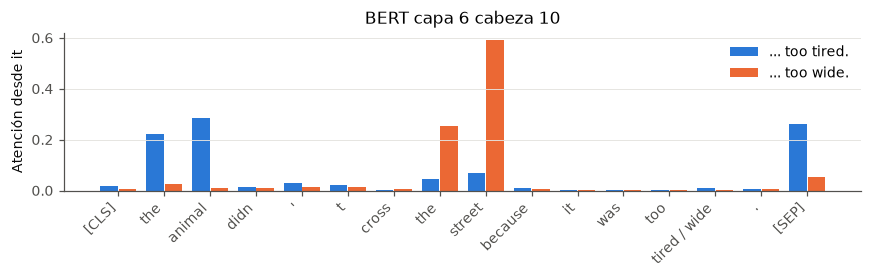

In [16]:
capa_it, cabeza_it = int(tabla_it.loc[0, "capa"]), int(tabla_it.loc[0, "cabeza"])
x = np.arange(len(tok_t))
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.bar(x - 0.2, A_t[capa_it, cabeza_it, i_it].numpy(), 0.38, color=AZUL, label="... too tired.")
ax.bar(x + 0.2, A_w[capa_it, cabeza_it, i_it].numpy(), 0.38, color=NARANJA, label="... too wide.")
etiquetas = [t if t not in ("tired", "wide") else "tired / wide" for t in tok_t]
ax.set_xticks(x, etiquetas, rotation=45, ha="right")
ax.set(ylabel="Atención desde it", title=f"BERT capa {capa_it} cabeza {cabeza_it}")
ax.grid(axis="x")
ax.legend()
fig.tight_layout()
fig.savefig("figures/it_bert.png")
plt.show()

La cabeza 10 de la capa 6 cumple los dos casos. Con tired, "it" asigna 0.28 a "animal" y 0.07 a "street". Con wide asigna 0.59 a "street" y 0.01 a "animal". 22 de 144 cabezas cumplen la condición y las cinco mejores están en las capas 4, 6 y 8.

## 9. GPT-2: máscara causal y attention sinks

Se verifica que todos los pesos sobre la diagonal sean cero y se mide la proporción de atención que recibe el primer token en cada capa con varias oraciones.

In [17]:
frases = [
    "The cat sat on the mat, and the cat was happy.",
    "The animal didn't cross the street because it was too tired.",
    "Deep learning models learn representations from large amounts of data.",
    "She opened the window because the room was too hot.",
    "Yesterday we visited the museum and saw an old painting.",
    "Attention lets every token look at every other token in the sequence.",
    "My brother bought a new car last week, but it broke down.",
    "Guatemala has many volcanoes, lakes and ancient Mayan cities.",
]
res_g = [atenciones(f, tok_gpt2, gpt2)[1] for f in frases]
res_b = [atenciones(f, tok_bert, bert)[1] for f in frases]

sobre_diag = max(A.triu(1).max().item() for A in res_g)
print("Máximo peso sobre la diagonal en GPT-2:", sobre_diag)
print("Todas las matrices son triangulares inferiores:", sobre_diag == 0.0)

# Atención al primer token, excluyendo la fila 0 que solo puede verse a sí misma
primer_g = torch.stack([A[:, :, 1:, 0].mean((1, 2)) for A in res_g]).mean(0)
base_uniforme = np.mean([np.mean([1 / (i + 1) for i in range(1, A.shape[-1])]) for A in res_g])
cls_b = torch.stack([A[:, :, :, 0].mean((1, 2)) for A in res_b]).mean(0)
sep_b = torch.stack([A[:, :, :, -1].mean((1, 2)) for A in res_b]).mean(0)

tabla_sink = pd.DataFrame({"capa": range(12), "GPT-2 primer token": primer_g.numpy(),
                           "BERT [CLS]": cls_b.numpy(), "BERT [SEP]": sep_b.numpy()})
print(f"Referencia uniforme causal: {base_uniforme:.3f}")
tabla_sink

Máximo peso sobre la diagonal en GPT-2: 0.0
Todas las matrices son triangulares inferiores: True
Referencia uniforme causal: 0.185


,capa,GPT-2 primer token,BERT [CLS],BERT [SEP]
0,0,0.244,0.159,0.077
1,1,0.412,0.434,0.094
2,2,0.419,0.368,0.103
3,3,0.561,0.270,0.237
4,4,0.580,0.048,0.525
5,5,0.751,0.037,0.601
6,6,0.728,0.036,0.579
7,7,0.815,0.028,0.567
8,8,0.753,0.034,0.587
9,9,0.821,0.064,0.508


In [18]:
# El sumidero depende de la posición y no de la palabra
pruebas = ["Cat sat on the mat.", "Yesterday the cat sat on the mat.", "However, the cat sat on the mat.",
           "1 cat sat on the mat.", "the the the the the the the the."]
filas = []
for p in pruebas:
    toks, A = atenciones(p, tok_gpt2, gpt2)
    filas.append({"oración": p, "primer token": toks[0],
                  "atención al primer token (capas 2 a 11)": A[2:, :, 1:, 0].mean().item()})
pd.DataFrame(filas)

,oración,primer token,atención al primer token (capas 2 a 11)
0,Cat sat on the mat.,Cat,0.781
1,Yesterday the cat sat on the mat.,Yesterday,0.736
2,"However, the cat sat on the mat.",However,0.731
3,1 cat sat on the mat.,1,0.754
4,the the the the the the the the.,the,0.687


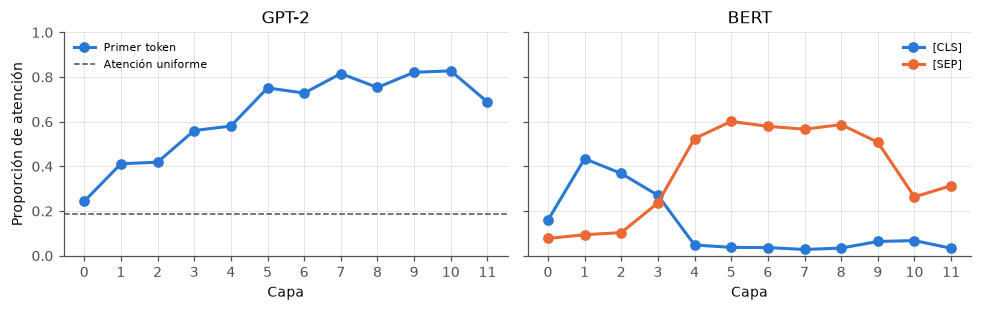

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(9, 2.9), sharey=True)
capas = np.arange(12)
ax[0].plot(capas, primer_g, "o-", color=AZUL, label="Primer token")
ax[0].axhline(base_uniforme, ls="--", color=GRIS, lw=1, label="Atención uniforme")
ax[0].set(xlabel="Capa", ylabel="Proporción de atención", title="GPT-2", ylim=(0, 1))
ax[1].plot(capas, cls_b, "o-", color=AZUL, label="[CLS]")
ax[1].plot(capas, sep_b, "o-", color=NARANJA, label="[SEP]")
ax[1].set(xlabel="Capa", title="BERT")
for a in ax:
    a.set_xticks(capas)
    a.legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/sinks.png")
plt.show()

Todas las matrices de GPT-2 tienen ceros sobre la diagonal. El primer token recibe 0.24 de la atención en la capa 0 y entre 0.69 y 0.83 desde la capa 5, frente a 0.185 de una distribución uniforme. Con distintas palabras iniciales el valor queda entre 0.69 y 0.78, por lo que depende de la posición y no del contenido. Esto coincide con los attention sinks de Xiao et al. (2023), donde el primer token absorbe la atención que sobra porque la softmax obliga a que los pesos sumen 1. BERT usa [SEP] de la misma forma entre las capas 4 y 9.

## 10. Entropía de la atención por capa

La entropía de cada fila mide qué tan repartida está la atención. En GPT-2 la fila i solo ve i + 1 tokens, por eso se reporta también la entropía normalizada por su máximo log(i + 1). Se excluye la fila 0 de GPT-2.

In [20]:
def entropia_capas(A, causal):
    n = A.shape[-1]
    Hrow = -(A * torch.log(A.clamp_min(1e-12))).sum(-1)    # (capas, cabezas, n)
    if causal:
        maximo = torch.log(torch.arange(1, n + 1, dtype=torch.float32))
        Hrow, maximo = Hrow[:, :, 1:], maximo[1:]
    else:
        maximo = torch.full((n,), math.log(n))
    return Hrow.mean((1, 2)), (Hrow / maximo).mean((1, 2))

ent_b = [entropia_capas(A, False) for A in res_b]
ent_g = [entropia_capas(A, True) for A in res_g]
tabla_ent = pd.DataFrame({
    "capa": range(12),
    "BERT entropía": torch.stack([e[0] for e in ent_b]).mean(0).numpy(),
    "GPT-2 entropía": torch.stack([e[0] for e in ent_g]).mean(0).numpy(),
    "BERT normalizada": torch.stack([e[1] for e in ent_b]).mean(0).numpy(),
    "GPT-2 normalizada": torch.stack([e[1] for e in ent_g]).mean(0).numpy(),
})
tabla_ent

,capa,BERT entropía,GPT-2 entropía,BERT normalizada,GPT-2 normalizada
0,0,2.018,1.284,0.758,0.679
1,1,1.564,1.409,0.587,0.720
2,2,1.410,1.282,0.530,0.662
3,3,1.585,1.025,0.595,0.530
4,4,1.364,0.880,0.512,0.451
5,5,1.154,0.756,0.433,0.391
6,6,1.164,0.848,0.437,0.436
7,7,1.149,0.618,0.431,0.318
8,8,1.322,0.808,0.496,0.417
9,9,1.492,0.594,0.561,0.306


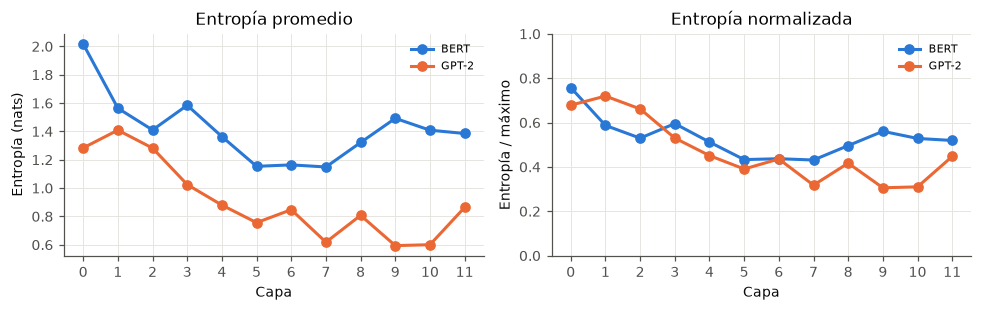

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(9, 2.9))
ax[0].plot(capas, tabla_ent["BERT entropía"], "o-", color=AZUL, label="BERT")
ax[0].plot(capas, tabla_ent["GPT-2 entropía"], "o-", color=NARANJA, label="GPT-2")
ax[0].set(xlabel="Capa", ylabel="Entropía (nats)", title="Entropía promedio")
ax[1].plot(capas, tabla_ent["BERT normalizada"], "o-", color=AZUL, label="BERT")
ax[1].plot(capas, tabla_ent["GPT-2 normalizada"], "o-", color=NARANJA, label="GPT-2")
ax[1].set(xlabel="Capa", ylabel="Entropía / máximo", title="Entropía normalizada", ylim=(0, 1))
for a in ax:
    a.set_xticks(capas)
    a.legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/entropia.png")
plt.show()

Las capas profundas atienden de forma más concentrada que las primeras. En BERT la entropía baja de 2.02 nats en la capa 0 a 1.15 en la capa 7 y sube a 1.39 en la capa 11. En GPT-2 baja de 1.28 a 0.59 en la capa 9. GPT-2 tiene menor entropía absoluta que BERT en todas las capas, en parte por el peso que pone en el primer token.

## 11. Resumen gráfico para el informe

Une en una figura la cabeza de correferencia, la atención al primer token y la entropía por capa. El color identifica al modelo en los dos paneles de la derecha.

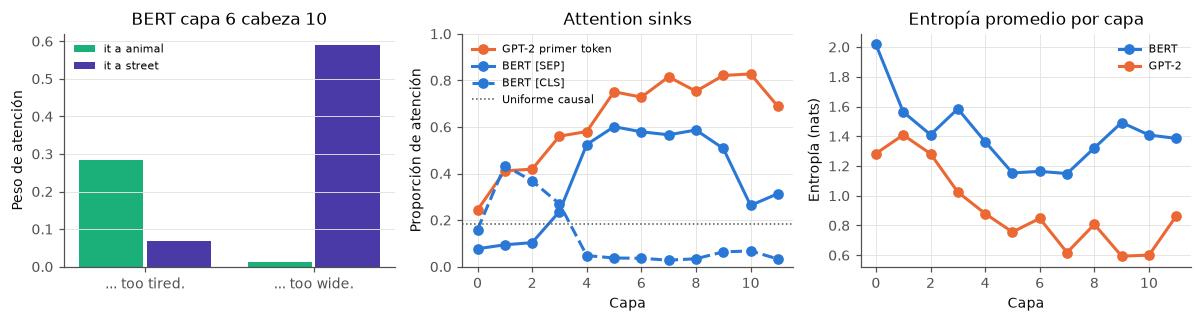

In [22]:
VIOLETA = "#4a3aa7"
fig, ax = plt.subplots(1, 3, figsize=(11, 3.0))
x = np.arange(2)
ax[0].bar(x - 0.2, [A_t[capa_it, cabeza_it, i_it, i_an].item(), A_w[capa_it, cabeza_it, i_it, i_an].item()], 0.38,
          color=AQUA, label="it a animal")
ax[0].bar(x + 0.2, [A_t[capa_it, cabeza_it, i_it, i_st].item(), A_w[capa_it, cabeza_it, i_it, i_st].item()], 0.38,
          color=VIOLETA, label="it a street")
ax[0].set_xticks(x, ["... too tired.", "... too wide."])
ax[0].set(ylabel="Peso de atención", title=f"BERT capa {capa_it} cabeza {cabeza_it}")
ax[0].grid(axis="x")

ax[1].plot(capas, primer_g, "o-", color=NARANJA, label="GPT-2 primer token")
ax[1].plot(capas, sep_b, "o-", color=AZUL, label="BERT [SEP]")
ax[1].plot(capas, cls_b, "o--", color=AZUL, label="BERT [CLS]")
ax[1].axhline(base_uniforme, ls=":", color=GRIS, lw=1, label="Uniforme causal")
ax[1].set(xlabel="Capa", ylabel="Proporción de atención", title="Attention sinks", ylim=(0, 1))

ax[2].plot(capas, tabla_ent["BERT entropía"], "o-", color=AZUL, label="BERT")
ax[2].plot(capas, tabla_ent["GPT-2 entropía"], "o-", color=NARANJA, label="GPT-2")
ax[2].set(xlabel="Capa", ylabel="Entropía (nats)", title="Entropía promedio por capa")
for a in ax[1:]:
    a.set_xticks(capas[::2])
for a in ax:
    a.legend(fontsize=7)
fig.tight_layout()
fig.savefig("figures/resumen_modelos.png")
plt.show()

## 12. Opcional: bertviz

Vista interactiva de BERT para cada oración, abierta en la cabeza de correferencia. Va dentro de un iframe porque VS Code no carga require.js en las salidas. También se guarda en `figures/bertviz_it.html` para abrirla en el navegador.

In [23]:
import html
from IPython.display import HTML, display

try:
    from bertviz import head_view
except ImportError:
    head_view = None
    print("bertviz no está instalado. Se instala con pip install bertviz")

if head_view is not None:
    REQUIRE = '<script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js"></script>'
    partes = []
    for i, s in enumerate([s_tired, s_wide]):
        enc = tok_bert(s, return_tensors="pt")
        with torch.no_grad():
            out = bert(**enc)
        # Pesos con 3 decimales para que el HTML pese menos
        atn = tuple(a.double().round(decimals=3) for a in out.attentions)
        vista = head_view(atn, tok_bert.convert_ids_to_tokens(enc["input_ids"][0]),
                          layer=capa_it, heads=[cabeza_it], html_action="return").data
        # require.js se carga una sola vez
        partes.append(f"<h4 style='font-family:sans-serif;margin:8px 0 0'>{s}</h4>"
                      + (vista if i == 0 else vista.replace(REQUIRE, "", 1)))
    pagina = ("<!DOCTYPE html><html><head><meta charset='utf-8'></head>"
              "<body style='background:white;color:black'>" + "".join(partes) + "</body></html>")
    with open("figures/bertviz_it.html", "w", encoding="utf-8") as f:
        f.write(pagina)
    display(HTML(f'<div><iframe srcdoc="{html.escape(pagina)}" width="100%" height="920" style="border:0"></iframe></div>'))